In [3]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

## Load Data

In [4]:
# Show all hidden columns
pd.set_option("display.max_columns", None)

df = pd.read_csv("airline_passenger_satisfaction.csv")
df.drop(columns="ID", inplace=True)
df.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
df.shape

(129880, 23)

In [6]:
df.describe()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## Clean Data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Gender                                  129880 non-null  object 
 1   Age                                     129880 non-null  int64  
 2   Customer Type                           129880 non-null  object 
 3   Type of Travel                          129880 non-null  object 
 4   Class                                   129880 non-null  object 
 5   Flight Distance                         129880 non-null  int64  
 6   Departure Delay                         129880 non-null  int64  
 7   Arrival Delay                           129487 non-null  float64
 8   Departure and Arrival Time Convenience  129880 non-null  int64  
 9   Ease of Online Booking                  129880 non-null  int64  
 10  Check-in Service                        1298

In [8]:
df.isnull().sum()

Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment                     0
Baggage Handling                  

In [9]:
avgDelay = df["Arrival Delay"].mean()
avgDelay

15.09112883918849

In [10]:
df.fillna({"Arrival Delay": avgDelay}, inplace=True)
df.isnull().sum()

Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                    

## Encode Data

In [11]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction'], dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for c in df.select_dtypes(include="object").drop(columns="Satisfaction").columns:
    df[c] = encoder.fit_transform(df[c])
df.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,48,0,0,0,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,0,35,1,0,0,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,1,41,1,0,0,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,1,50,1,0,0,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,0,49,1,0,0,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [13]:
df.dtypes

Gender                                      int32
Age                                         int64
Customer Type                               int32
Type of Travel                              int32
Class                                       int32
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness                                 int64
Food and Drink                              int64
In-flight Service                           int64
In-flight Wifi Service                      int64


## Filter Data

In [14]:
df[["Gender", "Age", "Type of Travel"]].head()

,Gender,Age,Type of Travel
0,1,48,0
1,0,35,0
2,1,41,0
3,1,50,0
4,0,49,0


In [15]:
df.loc[2:5, ["Gender", "Age", "Flight Distance"]]

,Gender,Age,Flight Distance
2,1,41,853
3,1,50,1905
4,0,49,3470
5,1,43,3788


In [16]:
df.loc[df["Age"] > 50, ["Gender", "Age", "Flight Distance"]].head()

,Gender,Age,Flight Distance
7,0,60,853
14,1,52,853
15,1,70,821
17,0,61,821
21,0,70,853


## Models

In [17]:
# Model input
X = df.drop(columns="Satisfaction")
X.head(3)

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,1,48,0,0,0,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5
1,0,35,1,0,0,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5
2,1,41,1,0,0,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3


In [18]:
# Model output
y = df["Satisfaction"]
y.tail(3)

129877    Neutral or Dissatisfied
129878                  Satisfied
129879    Neutral or Dissatisfied
Name: Satisfaction, dtype: object

### Decision Tree

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X.shape

(129880, 22)

In [20]:
X_train.shape

(103904, 22)

In [21]:
X_test.shape

(25976, 22)

In [22]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [23]:
y_predicted = model.predict(X_test)
len(y_predicted)

25976

In [24]:
accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.9460655990144748

### Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.9633122882660918

### KNeighbors Classifier

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.7539267015706806

### Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.8746920234062211

## Prediction without Passenger Feedback

In [37]:
X = df[["Gender", "Age", "Customer Type", "Type of Travel", "Class", "Flight Distance", "Departure Delay", "Arrival Delay"]]
X.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay
0,1,48,0,0,0,821,2,5.0
1,0,35,1,0,0,821,26,39.0
2,1,41,1,0,0,853,0,0.0
3,1,50,1,0,0,1905,0,0.0
4,0,49,1,0,0,3470,0,1.0


In [38]:
y = df["Satisfaction"]
y.head(3)

0    Neutral or Dissatisfied
1                  Satisfied
2                  Satisfied
Name: Satisfaction, dtype: object

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)

accuracy = accuracy_score(y_test, y_predicted)
accuracy

0.7629350169387127

### Manual Input Data

In [40]:
X.iloc[:0].to_dict()

{'Gender': {},
 'Age': {},
 'Customer Type': {},
 'Type of Travel': {},
 'Class': {},
 'Flight Distance': {},
 'Departure Delay': {},
 'Arrival Delay': {}}

In [54]:
manual_input = {
 'Gender': [1,0 ],
 'Age': [35, 25],
 'Customer Type': [0, 1],
 'Type of Travel': [0, 0],
 'Class': [1, 1],
 'Flight Distance': [1200, 600],
 'Departure Delay': [0, 10],
 'Arrival Delay': [0, 10]
}
manual_df = pd.DataFrame(manual_input)
model.predict(manual_df)

array(['Neutral or Dissatisfied', 'Neutral or Dissatisfied'], dtype=object)

## Export Model

In [ ]:
import joblib

model_name = "PredictPassengerSatisfaction.joblib"
joblib.dump(model, model_name)
pretrained_model = joblib.load(model_name)
pretrained_model.predict(manual_df)

## Charts

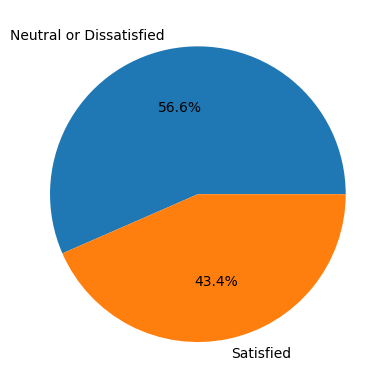

In [197]:
plt.pie(df["Satisfaction"].value_counts(), labels=["Neutral or Dissatisfied", "Satisfied"], autopct="%1.1f%%")
plt.show()

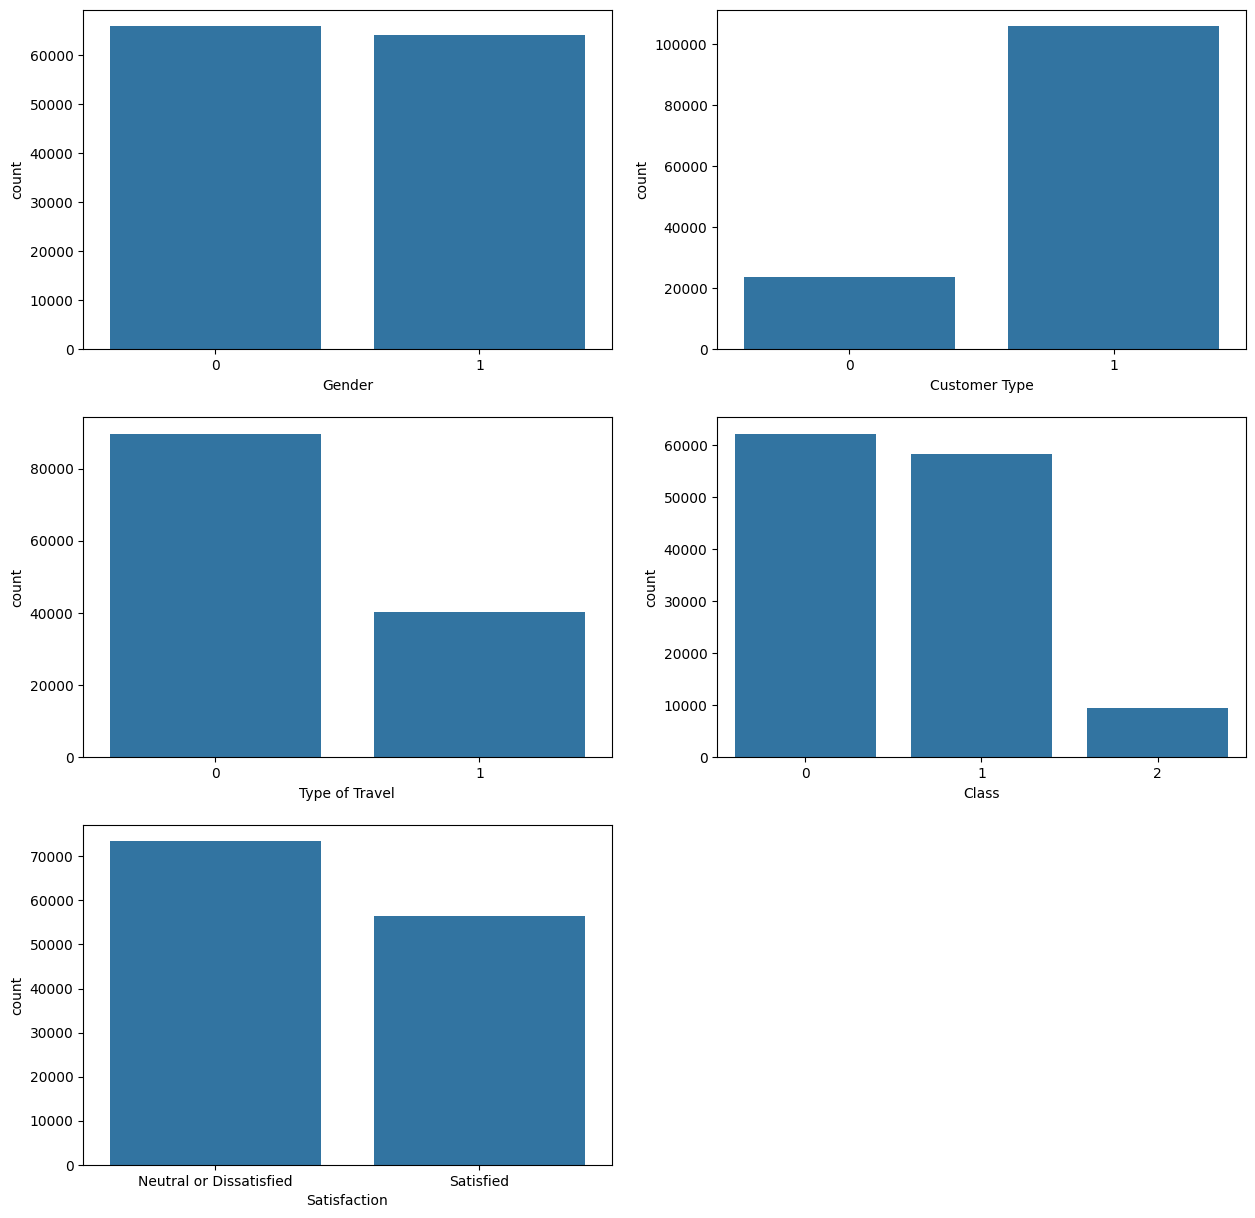

In [198]:
cols = ["Gender", "Customer Type", "Type of Travel", "Class", "Satisfaction"]
plt.figure(figsize=(15,15))

for i, col in enumerate(cols):
    plt.subplot(3, 2, i+1)
    sn.countplot(x=col, data=df)
plt.show()   

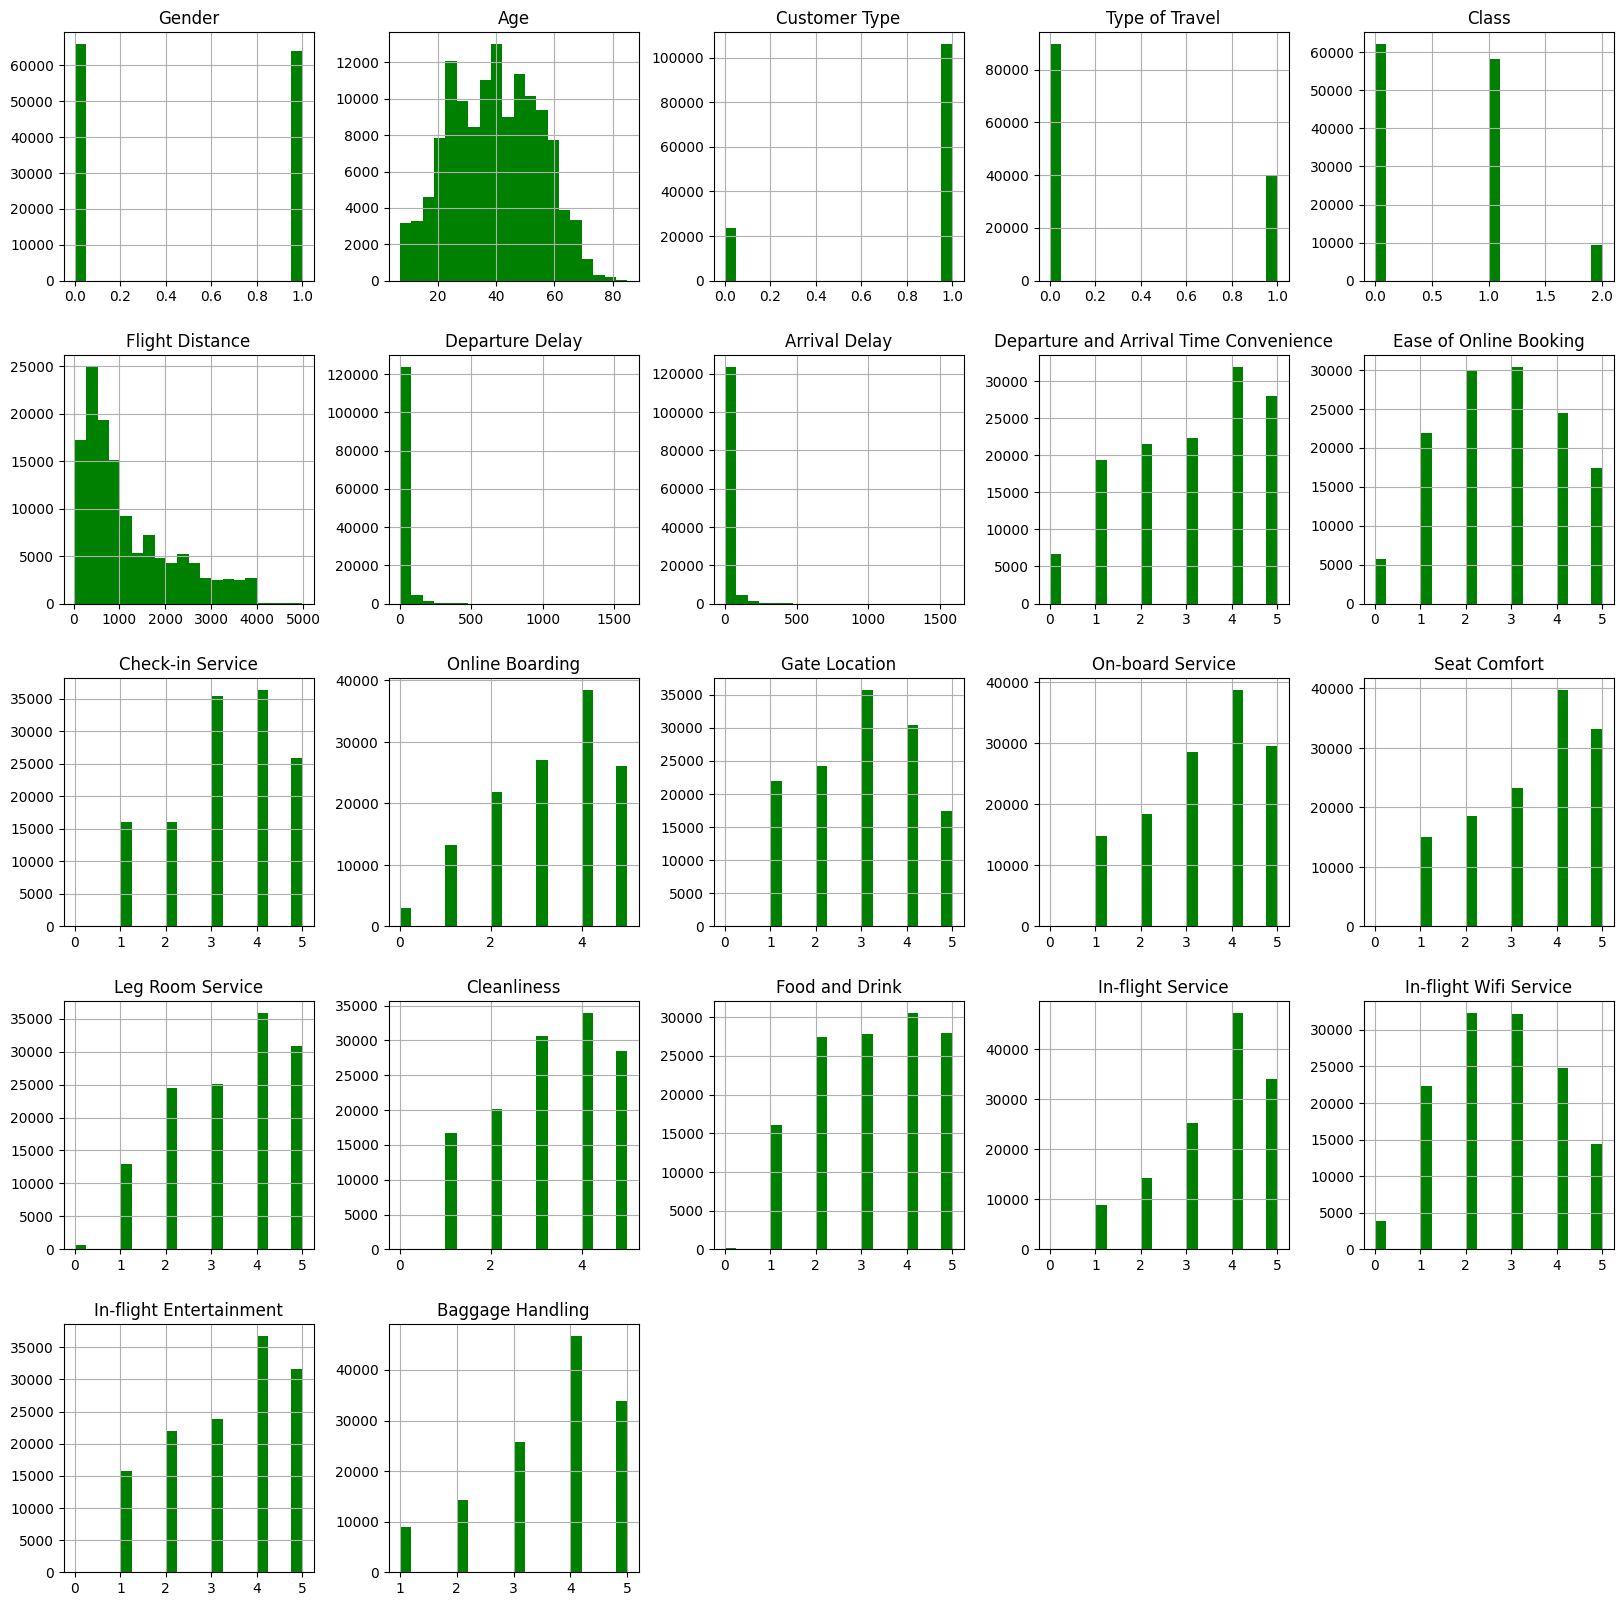

In [199]:
df.hist(bins=20, figsize=(20,20), color="green")
plt.show()

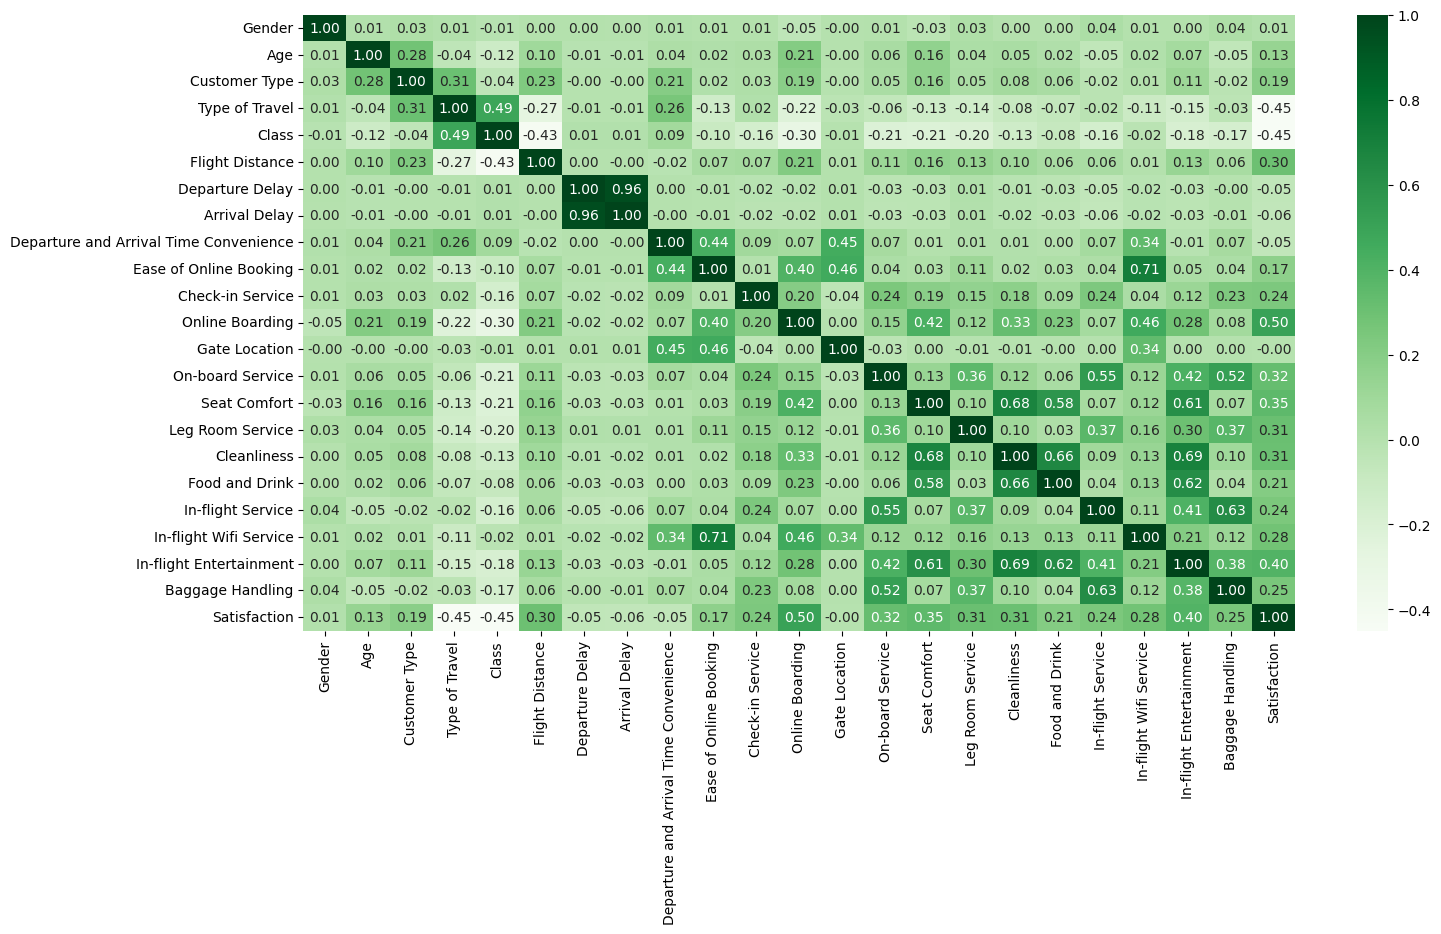

In [200]:
# Feature correlation
encoder = LabelEncoder()
df["Satisfaction"] = encoder.fit_transform(df["Satisfaction"])

plt.figure(figsize=(16,8))
sn.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Greens")
plt.show()

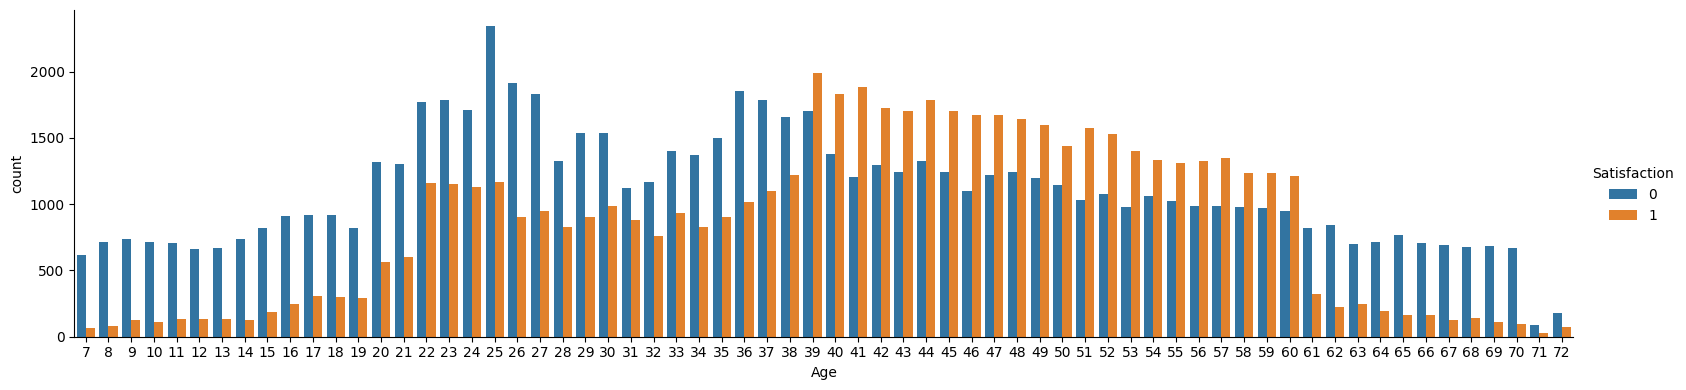

In [201]:
# Satisfaction dependency on age
sn.catplot(data=df, x="Age", height=4, aspect=4, kind="count", hue="Satisfaction", order=range(7,73))
plt.show()

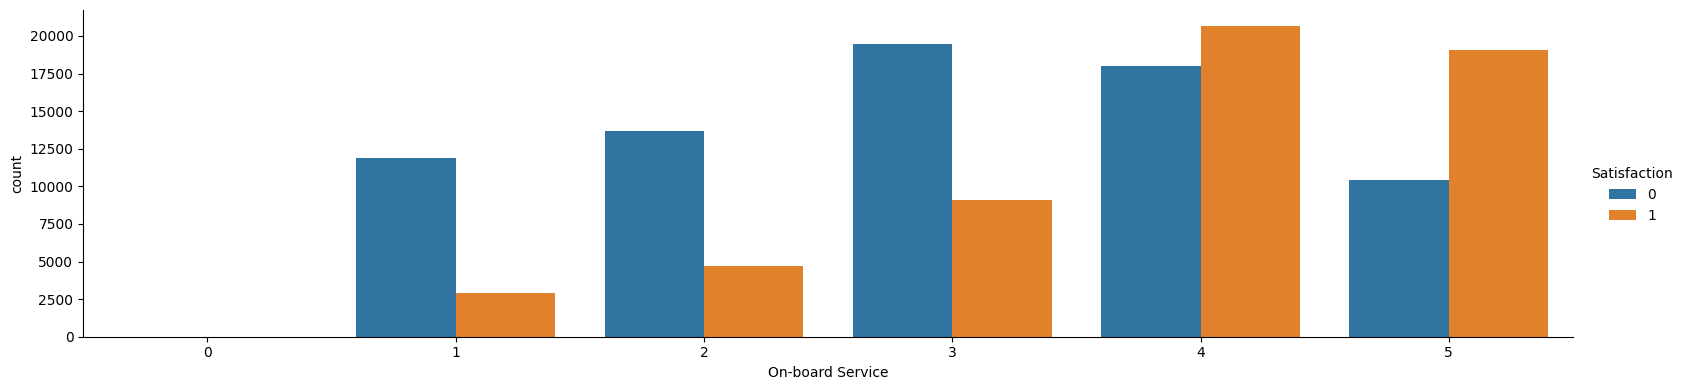

In [202]:
# Satisfaction dependency on on-board service
sn.catplot(data=df, x="On-board Service", height=4, aspect=4, kind="count", hue="Satisfaction")
plt.show()